In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
ruta = '/content/drive/MyDrive/PROBABILIDADyESTADISTICA/produccin-de-pozos-de-gas-y-petrleo-no-convencional.csv'

In [5]:
df = pd.read_csv(ruta)

In [6]:
fecha_minima = df["fecha_data"].min()
fecha_maxima = df["fechaingreso"].max()
print("Fecha mínima:", fecha_minima)
print("Fecha máxima:", fecha_maxima)

Fecha mínima: 2006-01-31
Fecha máxima: 2026-09-18 16:02:38.249307


In [7]:
#limpiamos los datos y establecemos las que tienen valores continuos para el analisis.


In [8]:
df.columns

Index(['idempresa', 'anio', 'mes', 'idpozo', 'prod_pet', 'prod_gas',
       'prod_agua', 'iny_agua', 'iny_gas', 'iny_co2', 'iny_otro', 'tef',
       'vida_util', 'tipoextraccion', 'tipoestado', 'tipopozo',
       'observaciones', 'fechaingreso', 'rectificado', 'habilitado',
       'idusuario', 'empresa', 'sigla', 'formprod', 'profundidad', 'formacion',
       'idareapermisoconcesion', 'areapermisoconcesion', 'idareayacimiento',
       'areayacimiento', 'cuenca', 'provincia', 'coordenadax', 'coordenaday',
       'tipo_de_recurso', 'proyecto', 'clasificacion', 'subclasificacion',
       'sub_tipo_recurso', 'fecha_data'],
      dtype='object')

In [9]:
df.dtypes

,0
idempresa,object
anio,int64
mes,int64
idpozo,int64
prod_pet,float64
prod_gas,float64
prod_agua,float64
iny_agua,float64
iny_gas,float64
iny_co2,float64


In [10]:
df.head()

,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,...,cuenca,provincia,coordenadax,coordenaday,tipo_de_recurso,proyecto,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data
0,YSUR,2016,1,155255,821.180,2110.430,259.19,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-67.810494,-39.024280,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2016-01-31
1,YSUR,2018,1,134778,0.000,6.130,4.97,0.0,0.0,0.0,...,NEUQUINA,Neuquén,-69.795986,-38.946347,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31
2,YSUR,2017,1,157125,236.740,911.520,63.15,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-67.810568,-39.024641,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,DESARROLLO,TIGHT,2017-01-31
3,YSUR,2018,1,130297,4.309,204.757,10.18,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-67.881623,-39.014652,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2018-01-31
4,YSUR,2016,1,132771,68.420,738.870,31.84,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-67.838082,-39.019110,NO CONVENCIONAL,GAS PLUS,EXPLOTACION,DESARROLLO,TIGHT,2016-01-31


In [11]:
df.tail()

,idempresa,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,...,cuenca,provincia,coordenadax,coordenaday,tipo_de_recurso,proyecto,clasificacion,subclasificacion,sub_tipo_recurso,fecha_data
426085,ACO,2023,12,164872,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-68.099940,-38.174340,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,DESARROLLO,TIGHT,2023-12-31
426086,ACO,2023,12,164503,179.446859,931.965354,422.357630,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-68.085408,-38.211980,NO CONVENCIONAL,Sin Proyecto,EXPLORACION,EXPLORATORIO PROFUNDO,TIGHT,2023-12-31
426087,ACO,2023,12,146101,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-67.963790,-38.460750,NO CONVENCIONAL,GAS PLUS,EXPLORACION,EXTENSION,TIGHT,2023-12-31
426088,ACO,2023,12,164374,282.644466,2582.094679,2.068688,0.0,0.0,0.0,...,NEUQUINA,Rio Negro,-68.106619,-38.178494,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,DESARROLLO,TIGHT,2023-12-31
426089,ACO,2023,12,3640,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,NEUQUINA,Neuquén,-68.452390,-37.954170,NO CONVENCIONAL,Sin Proyecto,EXPLOTACION,AVANZADA,SHALE,2023-12-31


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426090 entries, 0 to 426089
Data columns (total 40 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   idempresa               426090 non-null  object 
 1   anio                    426090 non-null  int64  
 2   mes                     426090 non-null  int64  
 3   idpozo                  426090 non-null  int64  
 4   prod_pet                426090 non-null  float64
 5   prod_gas                426090 non-null  float64
 6   prod_agua               426090 non-null  float64
 7   iny_agua                426090 non-null  float64
 8   iny_gas                 426090 non-null  float64
 9   iny_co2                 426090 non-null  float64
 10  iny_otro                426090 non-null  float64
 11  tef                     426090 non-null  float64
 12  vida_util               9078 non-null    float64
 13  tipoextraccion          425472 non-null  object 
 14  tipoestado          

In [13]:
df.shape

(426090, 40)

In [14]:
df.isnull().sum()

,0
idempresa,0
anio,0
mes,0
idpozo,0
prod_pet,0
prod_gas,0
prod_agua,0
iny_agua,0
iny_gas,0
iny_co2,0


In [15]:
df.nunique()

,0
idempresa,55
anio,21
mes,12
idpozo,5126
prod_pet,148597
prod_gas,194050
prod_agua,136551
iny_agua,639
iny_gas,573
iny_co2,1


In [16]:
df.describe()

,anio,mes,idpozo,prod_pet,prod_gas,prod_agua,iny_agua,iny_gas,iny_co2,iny_otro,tef,vida_util,idusuario,profundidad,coordenadax,coordenaday
count,426090.000000,426090.000000,426090.000000,426090.000000,426090.000000,426090.000000,426090.000000,4.260900e+05,426090.0,426090.0,426090.000000,9078.000000,426090.000000,426090.000000,426090.000000,426090.000000
mean,2020.930939,6.447652,151233.707142,337.554930,630.118237,190.990510,27.860710,3.492200e+01,0.0,0.0,21.975706,135.176730,358.649816,3772.955497,-68.834299,-38.961463
std,4.139032,3.411743,18218.088970,944.817431,1633.622865,631.901816,903.586174,8.528174e+03,0.0,0.0,12.178873,794.712398,69.421259,6526.373457,0.713868,2.460883
min,2006.000000,1.000000,3640.000000,-0.001000,-12.267000,0.000000,0.000000,0.000000e+00,0.0,0.0,0.000000,0.000000,3.000000,0.000000,-71.998310,-69.415770
25%,2018.000000,4.000000,146949.000000,0.000000,8.259281,0.000000,0.000000,0.000000e+00,0.0,0.0,14.670000,0.000000,334.000000,2859.700000,-69.179097,-38.757643
50%,2022.000000,6.000000,156471.000000,7.890000,103.330000,12.740000,0.000000,0.000000e+00,0.0,0.0,29.208000,0.000000,334.000000,3275.000000,-68.857000,-38.470630
75%,2024.000000,9.000000,160410.000000,125.777625,448.997500,87.358857,0.000000,0.000000e+00,0.0,0.0,30.650000,0.000000,381.000000,4712.000000,-68.494680,-38.314397
max,2026.000000,12.000000,167559.000000,26593.261000,40086.800000,34792.950000,70278.850000,3.569000e+06,0.0,0.0,79.340000,11415.210000,498.000000,378939.000000,-38.590070,-24.116560


In [17]:
nulos = df['vida_util'].isnull().sum()
total = len(df)
porcentaje = nulos / total * 100
print(f"Nulos: {nulos} ({porcentaje:.2f}%)")

Nulos: 417012 (97.87%)


In [18]:
print("Tipo de recurso:", df['tipo_de_recurso'].unique())
print()

Tipo de recurso: ['NO CONVENCIONAL']



In [19]:
print("Cuencas:")
print(df['cuenca'].value_counts())
print()

Cuencas:
cuenca
NEUQUINA           408858
AUSTRAL             16406
GOLFO SAN JORGE       641
NOROESTE              185
Name: count, dtype: int64



In [20]:
print("Provincias:")
print(df['provincia'].value_counts())


Provincias:
provincia
Neuquén       376018
Rio Negro      29659
Santa Cruz     16778
Mendoza         3181
Chubut           269
Salta            185
Name: count, dtype: int64


In [21]:
#Analisis descriptivo


In [22]:
col =  'prod_pet'

In [23]:
#MEDIDAS DE TENDENCIA CENTRAL

In [24]:
media = df[col].mean()
mediana = df[col].median()
moda = df[col].mode() # NO CALCULAR NO ES MUY UTIL para este caso

print()
print(f"media: {media:.2f}")
print(f"mediana: {mediana:.2f}")
print(f"moda: {moda.values[0]:.2f}")




media: 337.55
mediana: 7.89
moda: 0.00


In [25]:
#MEDIDAS DE DISPERSION

In [40]:
col = 'prod_pet'
desviacion_estandar = df[col].std()
rango = df[col].max() - df[col].min()
maximo = df[col].max()
minimo = df[col].min()
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

print(f"desviacion estandar: {desviacion_estandar:.2f}")
print(f"rango: {rango:.2f}")
print(f"maximo: {maximo:.2f}")
print(f"minimo: {minimo:.2f}")
print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")

desviacion estandar: 944.82
rango: 26593.26
maximo: 26593.26
minimo: -0.00
Q1: 0.00
Q3: 125.78
IQR: 125.78


In [27]:
#FORMA DE DISTRIBUCION

In [41]:
skewness = df[col].skew()
kurtosis = df[col].kurtosis()

print()
print(f"skewness: {skewness:.2f}")
print(f"kurtosis: {kurtosis:.2f}")


skewness: 4.92
kurtosis: 34.30


In [29]:
col = 'prod_pet'

ceros = (df[col] == 0).sum()
positivos = (df[col] > 0).sum()
negativos = (df[col] < 0).sum()
total = len(df)

print(f"Total de registros:  {total}")
print(f"Ceros:               {ceros} ({ceros/total*100:.2f}%)")
print(f"Positivos:           {positivos} ({positivos/total*100:.2f}%)")
print(f"Negativos:           {negativos} ({negativos/total*100:.2f}%)")
print()
print(f"¿Cuál es el mínimo?  {df[col].min()}")
print(f"¿Cuál es el máximo?  {df[col].max()}")

Total de registros:  426090
Ceros:               149646 (35.12%)
Positivos:           276443 (64.88%)
Negativos:           1 (0.00%)

¿Cuál es el mínimo?  -0.001
¿Cuál es el máximo?  26593.261


In [30]:
cero = (df[col] == 0 ).sum()
positivo = (df[col] > 0 ).sum()
negativo = (df[col] < 0 ).sum()
total =len(df)
print(f"cero: {ceros}  {ceros/total*100:.2f}%)")
print(f"positivo: {positivo}  {positivo/total*100:.2f}%)")
print(f"negativo: {negativo}  {negativo/total*100:.2f}%)")

cero: 149646  35.12%)
positivo: 276443  64.88%)
negativo: 1  0.00%)


In [31]:
### tenemos ceros y en un porcentaje importante. Graficar con y sin ceros.

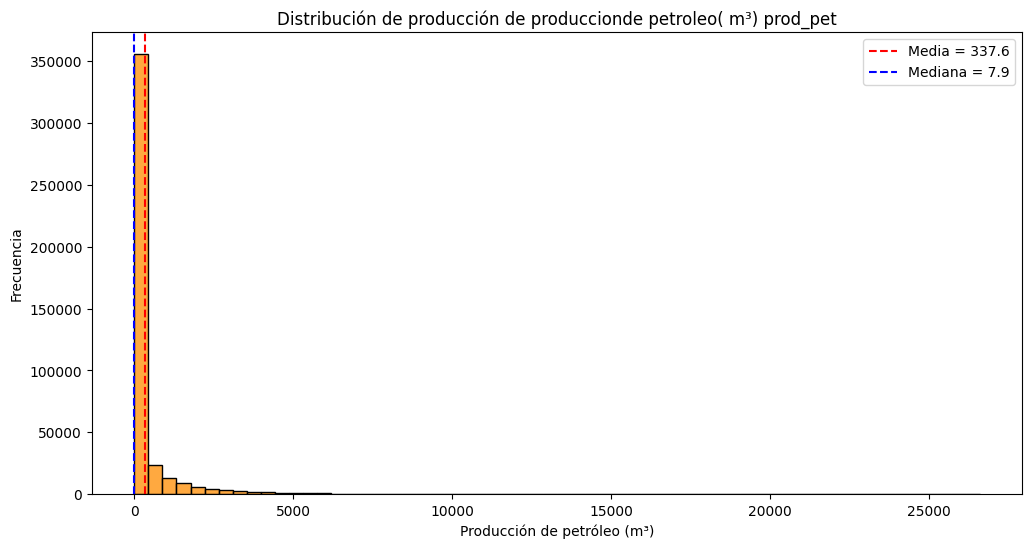

In [32]:
# Histograma 1 — todo el dataset
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x=col, bins=60, color='darkorange')
plt.axvline(df[col].mean(),   color='red',  linestyle='--', label=f'Media = {df[col].mean():.1f}')
plt.axvline(df[col].median(), color='blue', linestyle='--', label=f'Mediana = {df[col].median():.1f}')
plt.xlabel('Producción de petróleo (m³)')
plt.ylabel('Frecuencia')
plt.title(F'Distribución de producción de produccionde petroleo( m³) {col}')
plt.legend()
plt.show()


In [33]:
#solo positivos

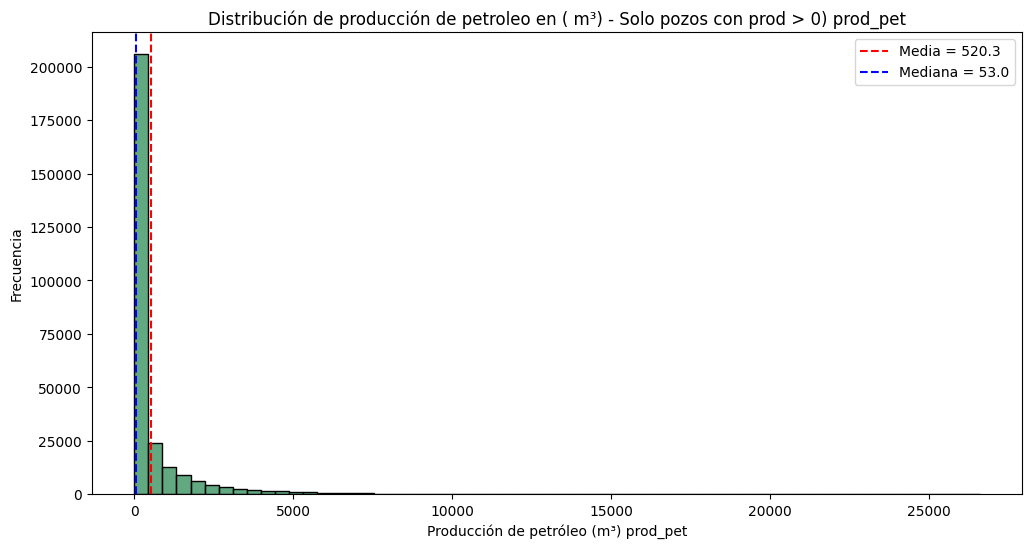

In [34]:
# Histograma 2 — solo positivos
df_pos = df[df[col] > 0]

plt.figure(figsize=(12, 6))
sns.histplot(data=df_pos, x=col, bins=60, color='seagreen')
plt.axvline(df_pos[col].mean(),   color='red',  linestyle='--', label=f'Media = {df_pos[col].mean():.1f}')
plt.axvline(df_pos[col].median(), color='blue', linestyle='--', label=f'Mediana = {df_pos[col].median():.1f}')
#plt.xlim(-100, 3000)   # ← acá limitás la vist
plt.xlabel(F'Producción de petróleo (m³) {col}')
plt.ylabel('Frecuencia')
plt.title(F'Distribución de producción de petroleo en ( m³) - Solo pozos con prod > 0) {col}')
plt.legend()
plt.show()

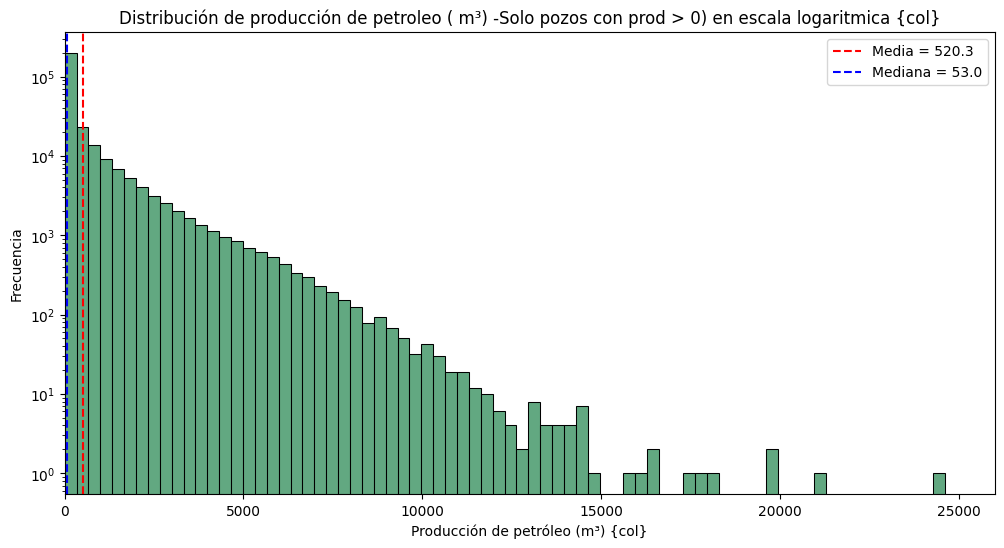

In [35]:
df_pos = df[df[col] > 0]

plt.figure(figsize=(12, 6))
sns.histplot(data=df_pos, x=col, bins=80, color='seagreen')
plt.axvline(df_pos[col].mean(),   color='red',  linestyle='--', label=f'Media = {df_pos[col].mean():.1f}')
plt.axvline(df_pos[col].median(), color='blue', linestyle='--', label=f'Mediana = {df_pos[col].median():.1f}')
plt.xlim(0, 26000)
plt.yscale('log')

plt.xlabel('Producción de petróleo (m³) {col}')
plt.ylabel('Frecuencia')
plt.title('Distribución de producción de petroleo ( m³) -Solo pozos con prod > 0) en escala logaritmica {col}')
plt.legend()
plt.show()

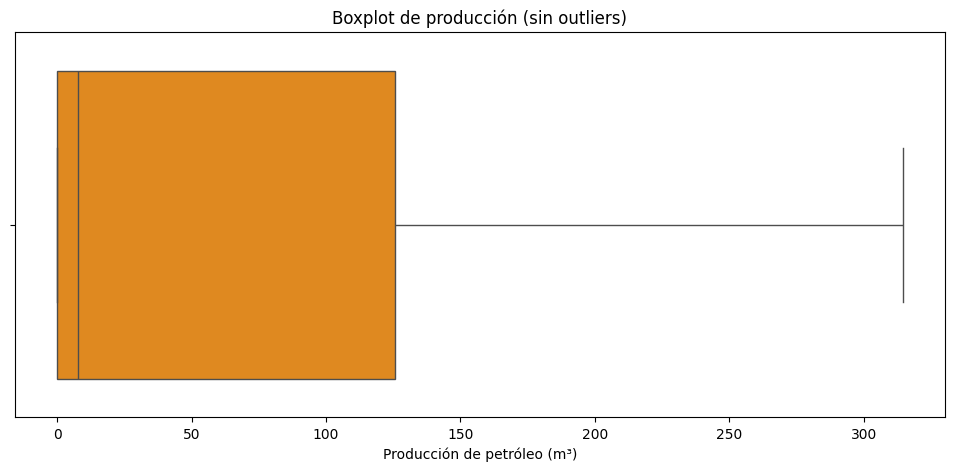

In [36]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x=col, color='darkorange', showfliers=False)
plt.xlabel('Producción de petróleo (m³)')
plt.title('Boxplot de producción (sin outliers)')
plt.show()

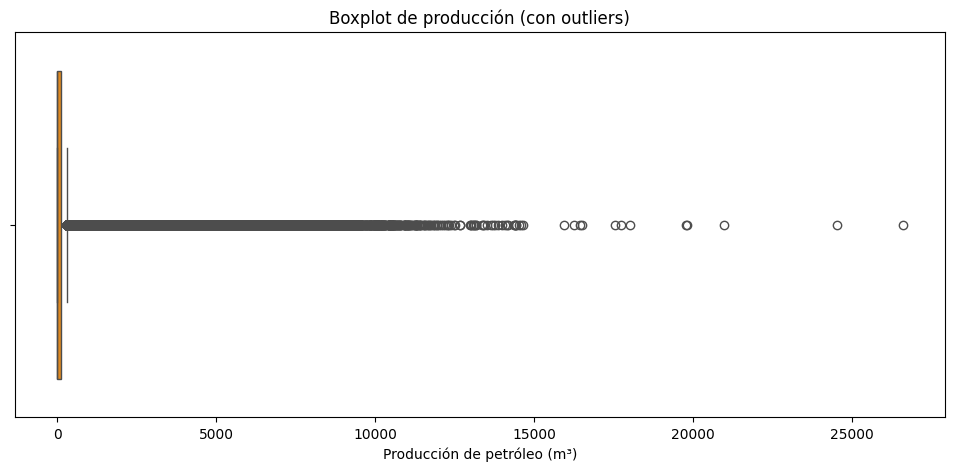

In [37]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x=col, color='darkorange')
plt.xlabel('Producción de petróleo (m³)')
plt.title('Boxplot de producción (con outliers)')
plt.show()

In [38]:
#El dataset de análisis contiene 426.090 registros, cada uno correspondiente a la producción mensual de un pozo, abarcando un período de aproximadamente 20 años.
#La columna seleccionada para el análisis es prod_pet (producción de petróleo, en m³).La media es de 337,55 m³ y la mediana de 7,89 m³. Dado que la media es muy
#superior a la mediana, la distribución presenta un sesgo positivo (cola hacia la derecha). La barra de mayor altura del histograma se ubica cerca de 0, lo que indica que
#la mayoría de los registros corresponden a pozos con producción muy baja o nula. Los valores altos, en la parte derecha del gráfico, elevan la media y generan la cola hacia
# la derecha. Al excluir los ceros del análisis, la frecuencia de datos disminuye, pero la asimetría hacia la derecha se mantiene. El coeficiente de asimetría de 4,92 confirma
#un sesgo positivo extremo, generado por la presencia de valores atípicos correspondientes a un número pequeño de pozos muy productivos. La curtosis de 34,29 indica colas
#extremadamente gruesas, lo cual se observa con mayor detalle en el histograma con escala logarítmica.

#El boxplot muestra que el 50% central de los datos está contenido en la caja (entre Q1 y Q3). El valor de Q1 para prod_pet es 0 m³, lo que indica que el 25% inferior de los
#registros tiene producción de petróleo nula. Por encima de Q3 (125,78 m³) se ubica el 25% superior, con una dispersión muy marcada debido a la presencia de pozos con producción
# excepcionalmente alta, entre los cuales se encuentra el máximo de 26.593,26 m³.